## Построение слойного графа Кэли и графа Грюнберга-Кегеля для циклических групп n-ного порядка

Нахождение элементов группы в циклическом виде

In [1]:
def cycle_group(n: int):
    """Возвращает элементы циклической группы n-ного порядка в циклической форме."""
    if n <= 0:
        raise ValueError(f"n должно быть положительным, получено {n}")
    
    group = []
    for step in range(n):
        element = []
        cur_cycle = [0]
        next_start = 1
        seen = set([0])
        for _ in range(n):
            next = (cur_cycle[-1] + step) % n
            # если цикл завершен
            if next == cur_cycle[0]:
                element.append(tuple(cur_cycle))
                while next_start in seen:
                    next_start += 1
                cur_cycle = [next_start]
                seen.add(next_start)
            else:
                cur_cycle.append(next)
                seen.add(next)
            
        group.append(element)
    
    return group

In [2]:
gr = cycle_group(6)
print("C6")
for i in range(len(gr)):
    print(f"Элемент {i}: {gr[i]}")

C6
Элемент 0: [(0,), (1,), (2,), (3,), (4,), (5,)]
Элемент 1: [(0, 1, 2, 3, 4, 5)]
Элемент 2: [(0, 2, 4), (1, 3, 5)]
Элемент 3: [(0, 3), (1, 4), (2, 5)]
Элемент 4: [(0, 4, 2), (1, 5, 3)]
Элемент 5: [(0, 5, 4, 3, 2, 1)]


In [3]:
gr = cycle_group(30)
print("C30")
for i in range(len(gr)):
    print(f"Элемент {i}: {gr[i]}")

C30
Элемент 0: [(0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,), (10,), (11,), (12,), (13,), (14,), (15,), (16,), (17,), (18,), (19,), (20,), (21,), (22,), (23,), (24,), (25,), (26,), (27,), (28,), (29,)]
Элемент 1: [(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29)]
Элемент 2: [(0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28), (1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29)]
Элемент 3: [(0, 3, 6, 9, 12, 15, 18, 21, 24, 27), (1, 4, 7, 10, 13, 16, 19, 22, 25, 28), (2, 5, 8, 11, 14, 17, 20, 23, 26, 29)]
Элемент 4: [(0, 4, 8, 12, 16, 20, 24, 28, 2, 6, 10, 14, 18, 22, 26), (1, 5, 9, 13, 17, 21, 25, 29, 3, 7, 11, 15, 19, 23, 27)]
Элемент 5: [(0, 5, 10, 15, 20, 25), (1, 6, 11, 16, 21, 26), (2, 7, 12, 17, 22, 27), (3, 8, 13, 18, 23, 28), (4, 9, 14, 19, 24, 29)]
Элемент 6: [(0, 6, 12, 18, 24), (1, 7, 13, 19, 25), (2, 8, 14, 20, 26), (3, 9, 15, 21, 27), (4, 10, 16, 22, 28), (5, 11, 17, 23, 29)]
Элемент 7: [(0

Построение слойного графа Кэли

In [ ]:
def plot_cayley_graph(n):
    """Строит слойный граф Кэли для циклической группы C_n."""
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.DiGraph() # ориентированный граф
    group = cycle_group(n)

    # распределяем элементы по слоям (ищем ord)
    layers = {}
    for i in range(len(group)):
        ord = len(group[i][0]) # ord - это длина первого цикла
        layers.setdefault(ord, []).append(i)

    pos = {} # элемент: (x, y)
    sorted_orders = sorted(layers.keys())

    for y_val, ord in enumerate(sorted_orders):
        elements = layers[ord]
        width = len(elements)
        for x_val, node in enumerate(elements):
            # центрируем вершины
            pos[node] = (x_val - width / 2, y_val)

    # добавляем вершины
    G.add_nodes_from(range(n))
    for i in range(n):
        # добавляем ребра
        G.add_edge(i, (i + 1) % n)

    # визуализируем
    nx.draw(G, pos, 
            with_labels=True, 
            node_color='lightblue', 
            node_size=600, 
            arrowsize=15,
            edge_color='gray',
            alpha=0.8)
    # создаем подписи порядков
    seen_y = set()
    for elem, p in pos.items():
        x, y = p
        if y in seen_y:
            continue
        seen_y.add(y)
        for ord, elems in layers.items():
            if elem in elems:
                plt.axhline(y=y, color='red', linestyle='--', alpha=0.2)
                plt.text(1.0, y, f'ord: {ord}', 
                    transform=plt.gca().get_yaxis_transform(), # привязка X к краю осей (0-1), Y к данным
                    ha='right',   # выравнивание текста по его правому краю
                    va='bottom',  # размещение текста над линией
                    color='red')
                break

    plt.title(f"Слойный граф Кэли для C{n}")
    plt.show()

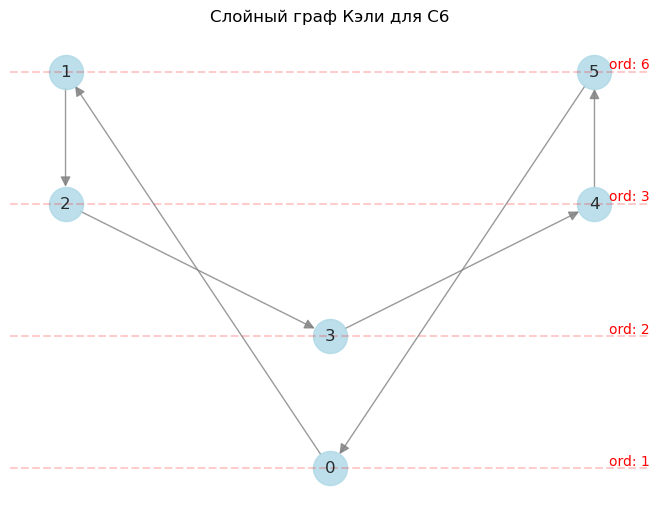

In [5]:
plot_cayley_graph(6)

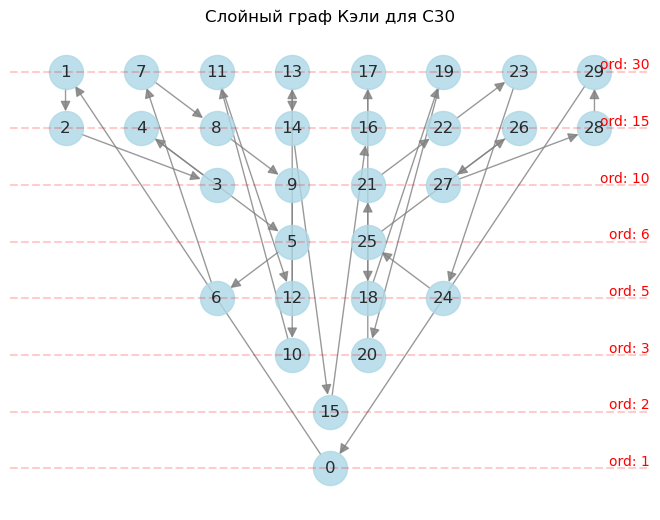

In [6]:
plot_cayley_graph(30)

Построение графа Грюнберга-Кегеля

In [7]:
def plot_gruenberg_kegel_graph(n):
    """Строит граф Грюнберга-Кегеля для циклической группы n-ного порядка."""
    import networkx as nx
    import matplotlib.pyplot as plt
    from itertools import combinations

    def get_primes(n):
        """Возвращает простые числа до n включительно."""
        res = set()
        while n % 2 == 0:
            res.add(2)
            n //= 2
        div = 3
        while div * div <= n:
            while n % div == 0:
                res.add(div)
                n //= div
            div += 2
        if n > 1:
            res.add(n)
        return res

    group = cycle_group(n)
    layers = set()
    for elem in group:
        ord = len(elem[0]) # ord - длина первого цикла
        layers.add(ord)

    G = nx.Graph() # неориентированный граф

    nodes = get_primes(n) # вершины - простые делители числа n
    edges = combinations(nodes, 2) # ребра связывают все вершины для циклической группы
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    pos = nx.spring_layout(G)  # Определяем позиции узлов для красоты
    nx.draw(G, pos, with_labels=True, node_color='lightblue', 
            node_size=800, font_weight='bold', edge_color='gray')

    plt.title(f"Граф Грюнберга-Кегеля для C{n}")
    plt.show()

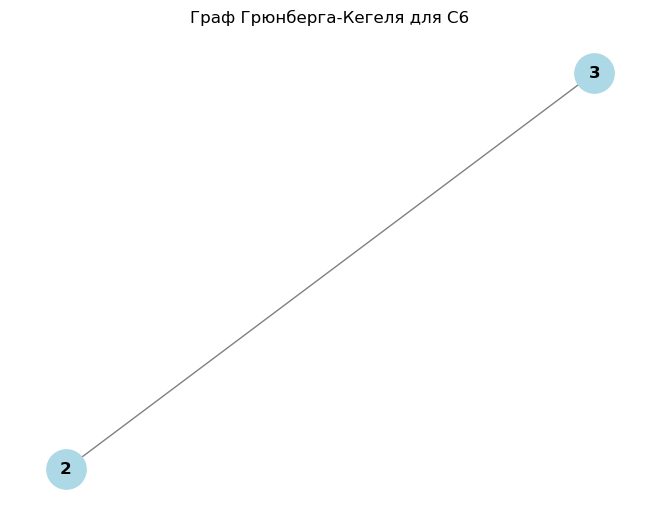

In [8]:
plot_gruenberg_kegel_graph(6)

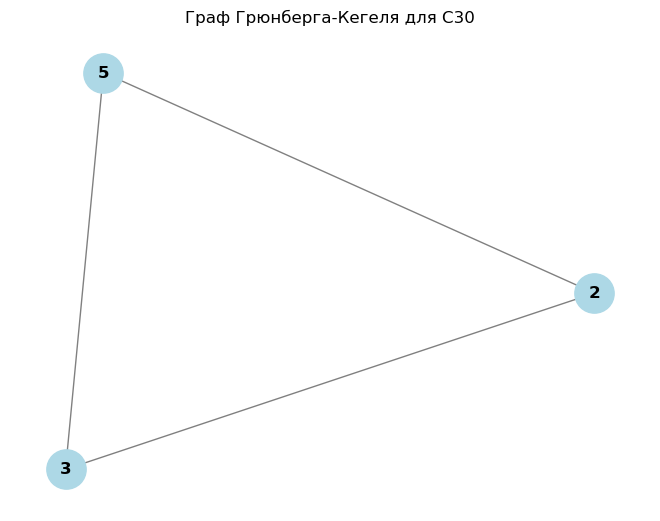

In [9]:
plot_gruenberg_kegel_graph(30)

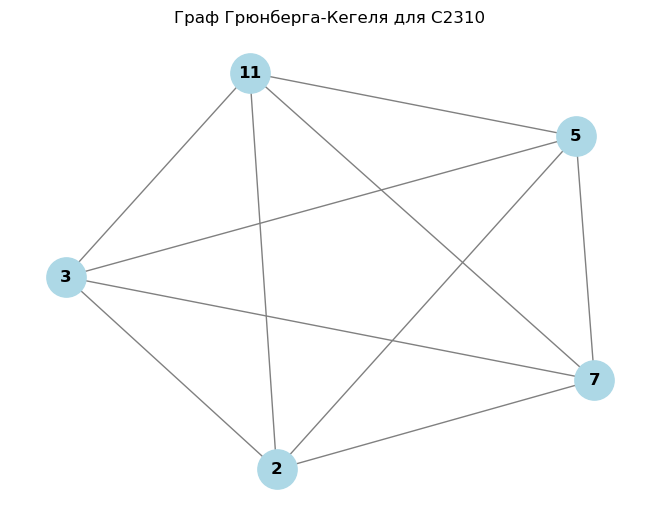

In [10]:
plot_gruenberg_kegel_graph(2*3*5*7*11)